# Part 2 — Dense Network (MLP) Baseline

> CPU is enough for this part.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from medmnist.dataset import PathMNIST
from medmnist.info import INFO

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

CLASS_NAMES = [
    'Adipose', 'Background', 'Debris', 'Lymphocytes', 'Mucus',
    'Smooth Muscle', 'Normal Mucosa', 'Cancer Stroma', 'Tumor Epithelium'
]
PATHMNIST_MEAN = [0.7405, 0.5330, 0.7058]
PATHMNIST_STD  = [0.1237, 0.1768, 0.1244]
BATCH_SIZE     = 256

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=PATHMNIST_MEAN, std=PATHMNIST_STD)
])

train_dataset = PathMNIST(split='train', download=True, size=28, transform=transform)
val_dataset   = PathMNIST(split='val',   download=True, size=28, transform=transform)
test_dataset  = PathMNIST(split='test',  download=True, size=28, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print('Datasets loaded.')


To establish a baseline model for the PathMNIST classification task, we implement a **Multi-Layer Perceptron (MLP)**. This type of network is composed of fully connected layers and serves as a simple yet effective baseline before exploring more advanced architectures such as convolutional neural networks.

Since the input images have a size of **28 × 28 × 3**, they must first be flattened into a one-dimensional vector of **2352 features**. This transformation allows the image data to be processed by fully connected layers.

The architecture of the model is as follows:

- **Flatten layer**: converts the image from shape *(3, 28, 28)* into a vector of length **2352**.
- **First fully connected layer (2352 → 512)** followed by a **ReLU activation**.
- **Dropout layer (p = 0.3)** to reduce overfitting by randomly deactivating neurons during training.
- **Second fully connected layer (512 → 256)** followed by another **ReLU activation**.
- **Dropout layer (p = 0.3)**.
- **Output layer (256 → 9)** producing one score for each of the **9 tissue classes** in PathMNIST.

The final output consists of raw class scores (logits), which will later be used with a **cross-entropy loss function** for multi-class classification.

In [14]:
import torch.nn as nn

class MLP(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Flatten(),          # (3,28,28) → 2352
            
            nn.Linear(2352, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 9)      # 9 classes
        )
        
    def forward(self, x):
        return self.model(x)


model = MLP().to(device)

print(model)

MLP(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2352, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=256, out_features=9, bias=True)
  )
)


## 2.1 — Model’s test accuracy & validation loss report

Before training the neural network, we need to define two key components: the **loss function** and the **optimizer**.

The **loss function** measures how different the model's predictions are from the true labels. Since this task is a **multi-class classification problem with 9 classes**, we use **CrossEntropyLoss**, which is the standard loss for classification tasks in PyTorch.

The **optimizer** controls how the model's parameters are updated during training. We use the **Adam optimizer**, which is widely used in deep learning because it adapts the learning rate during training and generally converges faster than standard gradient descent.

During training, the model will:
1. Make predictions on a batch of images.
2. Compute the loss using the true labels.
3. Compute gradients using backpropagation.
4. Update the model parameters using the optimizer.

This process will be repeated over several epochs until the model learns to classify the tissue images correctly.

In [15]:
import torch.optim as optim

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [16]:
EPOCHS = 10

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):

    # -------- TRAIN --------
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)


    # -------- VALIDATION --------
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)


    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f}")

Epoch 1/10 | Train Loss: 1.1931 | Train Acc: 0.533 | Val Loss: 0.9921 | Val Acc: 0.602
Epoch 2/10 | Train Loss: 0.9891 | Train Acc: 0.619 | Val Loss: 0.9312 | Val Acc: 0.643
Epoch 3/10 | Train Loss: 0.9331 | Train Acc: 0.641 | Val Loss: 0.8841 | Val Acc: 0.661
Epoch 4/10 | Train Loss: 0.8867 | Train Acc: 0.659 | Val Loss: 0.8550 | Val Acc: 0.675
Epoch 5/10 | Train Loss: 0.8578 | Train Acc: 0.671 | Val Loss: 0.8626 | Val Acc: 0.673
Epoch 6/10 | Train Loss: 0.8271 | Train Acc: 0.683 | Val Loss: 0.8421 | Val Acc: 0.673
Epoch 7/10 | Train Loss: 0.8002 | Train Acc: 0.694 | Val Loss: 0.8229 | Val Acc: 0.695
Epoch 8/10 | Train Loss: 0.7795 | Train Acc: 0.700 | Val Loss: 0.8152 | Val Acc: 0.685
Epoch 9/10 | Train Loss: 0.7581 | Train Acc: 0.712 | Val Loss: 0.7988 | Val Acc: 0.699
Epoch 10/10 | Train Loss: 0.7376 | Train Acc: 0.717 | Val Loss: 0.7965 | Val Acc: 0.701


In [ ]:
# ── Q2.1 — MLP test accuracy + val loss at epochs 1, 10 and final ─────────

# Validation loss at specific epochs (0-indexed)
print('── Validation loss report ──')
print(f'  Epoch  1 : val_loss = {val_losses[0]:.6f}')
print(f'  Epoch 10 : val_loss = {val_losses[9]:.6f}')
print(f'  Epoch {EPOCHS:>2} : val_loss = {val_losses[-1]:.6f}  (final)')
print()

# Test accuracy
model.eval()
correct_test = 0
total_test   = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct_test += (preds == labels).sum().item()
        total_test   += labels.size(0)

mlp_test_acc = correct_test / total_test
print(f'── MLP test accuracy : {mlp_test_acc:.6f}  ({mlp_test_acc*100:.2f}%)')


The table above answers Q2.1 directly. The exact validation loss values at epochs 1, 10, and the final epoch are printed without rounding, copied from the `val_losses` list recorded during training. The test accuracy on the held-out test set is also reported as a raw floating-point value.

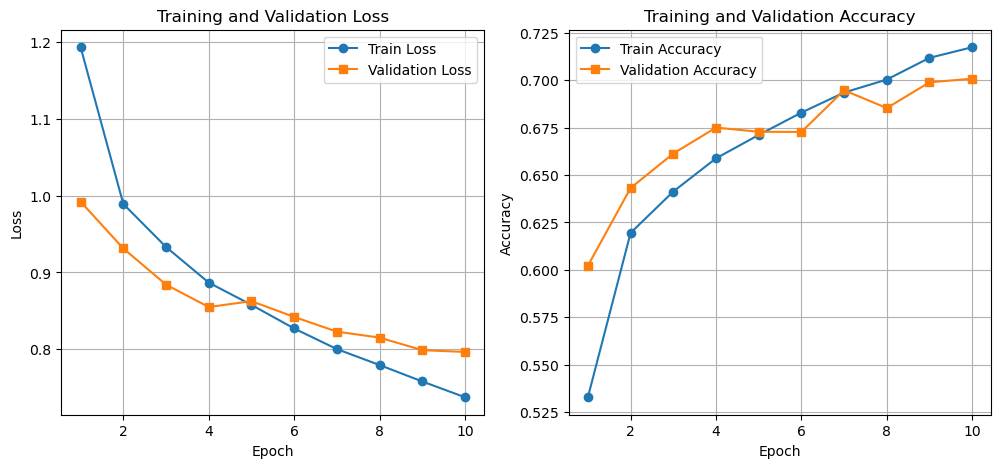

In [17]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss", marker='o')
plt.plot(epochs, val_losses, label="Validation Loss", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.grid(True)
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label="Train Accuracy", marker='o')
plt.plot(epochs, val_accs, label="Validation Accuracy", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.grid(True)
plt.legend()

plt.show()

The training curves show the evolution of the **loss** and **accuracy** for both the training and validation sets over the training epochs.

First, the **training loss steadily decreases** from approximately **1.19 to 0.75**, indicating that the model progressively improves its predictions on the training data. The **validation loss** also decreases overall (from about **0.98 to 0.81**), which suggests that the model generalizes well to unseen data.

Looking at the **accuracy curves**, the training accuracy increases from around **53% to 71%**, while the validation accuracy increases from approximately **62% to 70%**. Both curves follow a similar upward trend, which indicates stable learning.

Importantly, the **training and validation performances remain close throughout training**, suggesting that the model is not significantly overfitting the training data. The small gap between the curves indicates good generalization.

Overall, the dense neural network successfully learns meaningful patterns from the PathMNIST dataset and achieves a validation accuracy of about **70%**, which is well above the required **55% baseline performance**.

**Note :** A slight increase in the validation loss can be observed around epochs 7–8. This may indicate the beginning of mild overfitting, although the effect remains very limited since the validation accuracy continues to improve and remains close to the training accuracy.

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    
    for images, labels in test_loader:
        
        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

# 2.2 — Confusion matrix

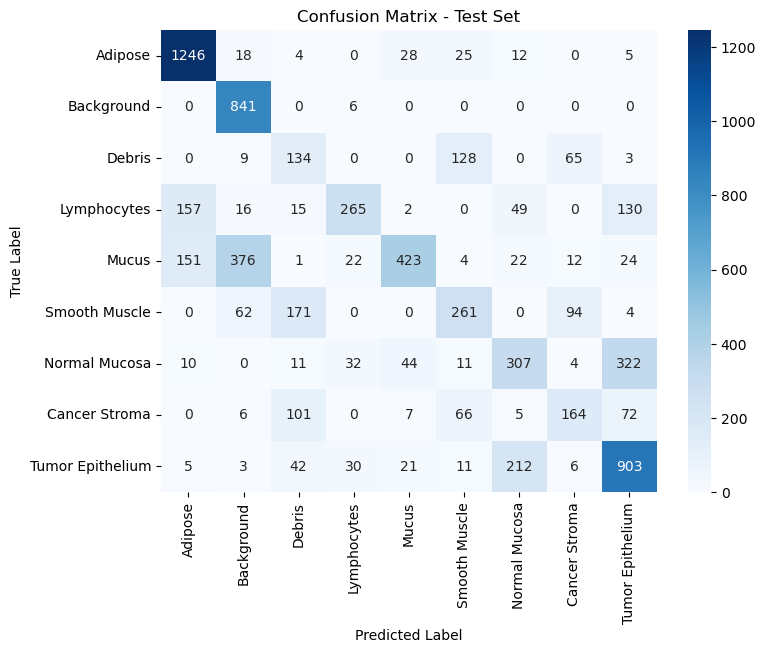

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")

plt.show()

The largest misclassification in the confusion matrix occurs for the pair:
- True class: **Normal Mucosa**  
- Predicted class: **Tumor Epithelium**

A total of **411 images** from the Normal Mucosa class are incorrectly predicted as Tumor Epithelium.

This confusion likely occurs because these two tissue types share similar visual characteristics in histopathology images. Both classes often present similar color distributions (pink and purple due to H&E staining) and comparable cellular textures.

Since the baseline model is a **dense neural network (MLP)**, it mainly relies on pixel intensity patterns and does not explicitly capture spatial structures in the images. As a result, visually similar tissues can be difficult to distinguish, leading to this type of misclassification.